In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [8]:
df=pd.read_csv('heart.csv')

In [9]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [10]:
X=df.drop(columns='target')
y=df.target

In [11]:
X.shape, y.shape

((303, 13), (303,))

In [12]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train.shape, X_test.shape

((242, 13), (61, 13))

In [14]:
std=StandardScaler()

In [15]:
X_train_tf=std.fit_transform(X_train)
X_test_tf=std.fit_transform(X_test)

In [16]:
X_train=pd.DataFrame(X_train_tf, columns=X_train.columns)
X_test=pd.DataFrame(X_test_tf, columns=X_test.columns)

In [46]:
lr=LogisticRegression()

In [47]:
lr.fit(X_train, y_train)

LogisticRegression()

In [48]:
y_pred=lr.predict(X_test)

Accuracy:  0.8852459016393442
Precision:  0.8787878787878788
Recall:  0.90625
F1:  0.8923076923076924
CM:  [[25  4]
 [ 3 29]]


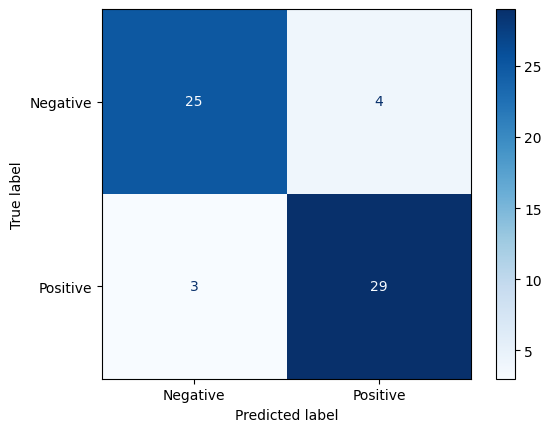

In [20]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1: ", f1_score(y_test, y_pred))
cm=confusion_matrix(y_test, y_pred)
print("CM: ", confusion_matrix(y_test, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [21]:
lr=DecisionTreeClassifier()

In [22]:
lr.fit(X_train, y_train)

DecisionTreeClassifier()

In [23]:
y_pred=lr.predict(X_test)

Accuracy:  0.819672131147541
Precision:  0.8888888888888888
Recall:  0.75
F1:  0.8135593220338984
CM:  [[26  3]
 [ 8 24]]


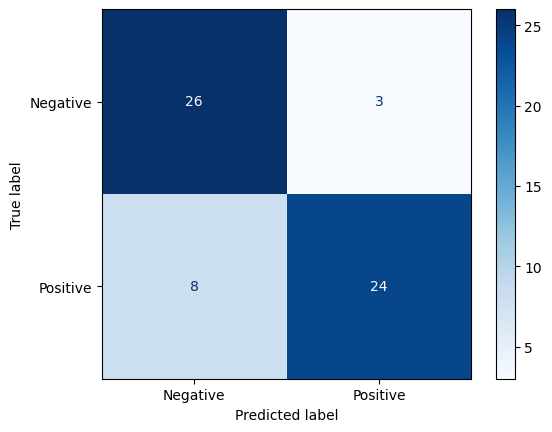

In [24]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1: ", f1_score(y_test, y_pred))
cm=confusion_matrix(y_test, y_pred)
print("CM: ", confusion_matrix(y_test, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [37]:
from sklearn.metrics import roc_curve, auc

In [49]:
y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [50]:
fpr, tpr, thresholds

(array([0.        , 0.        , 0.        , 0.03448276, 0.03448276,
        0.06896552, 0.06896552, 0.13793103, 0.13793103, 0.27586207,
        0.27586207, 0.48275862, 0.48275862, 1.        ]),
 array([0.     , 0.03125, 0.40625, 0.40625, 0.65625, 0.65625, 0.78125,
        0.78125, 0.90625, 0.90625, 0.96875, 0.96875, 1.     , 1.     ]),
 array([       inf, 0.99598519, 0.93976911, 0.93448545, 0.86348618,
        0.86156057, 0.81686414, 0.80032344, 0.63416746, 0.22163043,
        0.17363633, 0.10406883, 0.08794651, 0.00940585]))

In [55]:
thresholds.shape

(14,)

In [56]:
X_test.shape

(61, 13)

In [52]:
roc_auc = auc(fpr, tpr)

In [53]:
roc_auc

np.float64(0.9331896551724137)

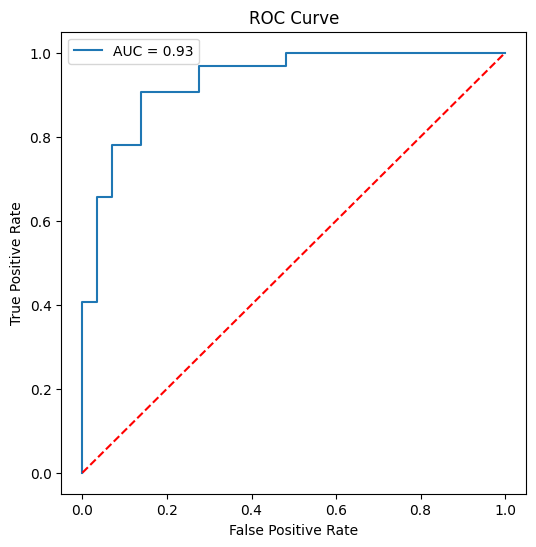

In [54]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle="--", color="red")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()